В данном проекте исследуется влияние новостей на динамику цен карбамида (азотное удобрение).

**Цель:** определить, улучшают ли рыночные новости прогнозирование цен на карбамид (urea_price) и какие типы новостей содержат наиболее полезную информацию.

## Загрузка данных

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
news = pd.read_csv('data/market_news.csv')
prices = pd.read_csv('data/prices.csv')

In [3]:
print(news.info())
news.head()

<class 'pandas.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   date      370 non-null    str  
 1   source    370 non-null    str  
 2   category  370 non-null    str  
 3   headline  370 non-null    str  
dtypes: str(4)
memory usage: 11.7 KB
None


,date,source,category,headline
0,2020-01-08,Интерфакс,Прочее,Опубликован годовой ESG-отчёт компании
1,2020-01-10,CRU,Фосфаты,DAP дешевеет из-за слабого спроса в Индии
2,2020-01-18,Профильный телеграм-канал,Логистика,"Ставки фрахта снижаются, логистика дешевеет"
3,2020-03-12,ICIS,Аммиак,Котировки аммиака пошли вниз на фоне слабого с...
4,2020-03-14,CRU,Прочее,Компания провела ежегодный день инвестора


In [5]:
print(prices.info())
prices.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  339 non-null    str    
 1   urea_price            339 non-null    float64
 2   dap_price             339 non-null    float64
 3   mop_price             339 non-null    float64
 4   gas_price             326 non-null    float64
 5   ammonia_price         339 non-null    float64
 6   brent_oil             339 non-null    float64
 7   usd_rub               339 non-null    float64
 8   freight_index         326 non-null    float64
 9   crop_price_index      339 non-null    float64
 10  sulphur_price         326 non-null    float64
 11  phosphate_rock_price  339 non-null    float64
 12  potash_supply_index   339 non-null    float64
 13  consensus_price_urea  339 non-null    float64
dtypes: float64(13), str(1)
memory usage: 37.2 KB
None


,date,urea_price,dap_price,mop_price,gas_price,ammonia_price,brent_oil,usd_rub,freight_index,crop_price_index,sulphur_price,phosphate_rock_price,potash_supply_index,consensus_price_urea
0,2020-01-06,378.4,600.0,464.1,28.0,486.0,72.5,65.02,2000.0,104.4,140.0,170.0,100.0,337.8
1,2020-01-13,338.2,564.2,457.7,25.4,423.5,71.4,64.68,1934.0,103.9,148.8,167.5,98.5,357.5
2,2020-01-20,365.6,553.7,484.5,27.7,458.6,72.1,65.34,1887.0,109.8,141.5,150.7,98.6,366.5


Преобразуем дату из строки в datetime формат

In [18]:
prices['date'] = pd.to_datetime(prices.date)
news['date'] = pd.to_datetime(news.date)

news.date[0], prices.date[0]

(Timestamp('2020-01-08 00:00:00'), Timestamp('2020-01-06 00:00:00'))

Убедимся в том, что новости и цены отсортированы по дате

In [21]:
prices.date.is_monotonic_increasing

True

In [22]:
news.date.is_monotonic_increasing

True

## EDA

### Исследование цен (prices.csv)

#### Проверка качества данных

Проверка на пропуски:

In [25]:
prices.isna().sum()

date                     0
urea_price               0
dap_price                0
mop_price                0
gas_price               13
ammonia_price            0
brent_oil                0
usd_rub                  0
freight_index           13
crop_price_index         0
sulphur_price           13
phosphate_rock_price     0
potash_supply_index      0
consensus_price_urea     0
dtype: int64

In [79]:
cols_with_nans = [col for col in prices.columns if prices[col].isna().sum() != 0]
cols_with_nans

['gas_price', 'freight_index', 'sulphur_price']

В колонках `gas_price`, `freight_index` и `sulphur_price` ровно по 13 пропусков. Посмотрим, есть ли между ними какая-то связь, например, идут ли они подряд или встречаются одновременно в нескольких колонках

In [80]:
prices[prices.isna().any(axis=1)][['date'] + cols_with_nans]

,date,gas_price,freight_index,sulphur_price
6,2020-02-17,23.3,1744.0,NaN
10,2020-03-16,25.4,NaN,NaN
15,2020-04-20,28.9,NaN,130.6
16,2020-04-27,29.6,2168.0,NaN
33,2020-08-24,29.1,1778.0,NaN
38,2020-09-28,NaN,1718.0,103.7
40,2020-10-12,NaN,2079.0,115.0
46,2020-11-23,33.1,2054.0,NaN
63,2021-03-22,40.6,3141.0,NaN
76,2021-06-21,NaN,3673.0,137.0


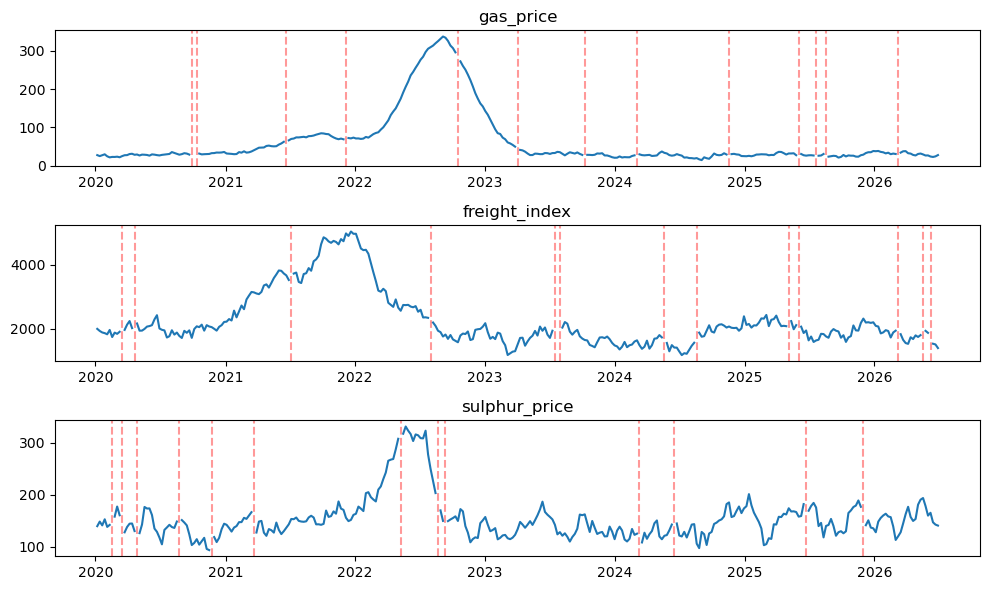

In [125]:
fig, axes = plt.subplots(3, 1, figsize=(10, 6))
axes = axes.flatten()
for i, col in enumerate(cols_with_nans):
    axes[i].plot(prices.date, prices[col])
    nan_dates = prices[prices[col].isna()].date
    for date in nan_dates:
        axes[i].axvline(date, color='red', alpha=0.4, linestyle='--')
    axes[i].set_title(col)
plt.tight_layout()

На графиках видно, что пропуски разбросаны хаотично и редко встречаются в разных колонках в одни и те же даты. Поскольку пропуски изолированы (не идут сплошными блоками), можем воспользоваться методом `ffill` (заполнение предыдущим известным значением).

Осталось пропусков: 0


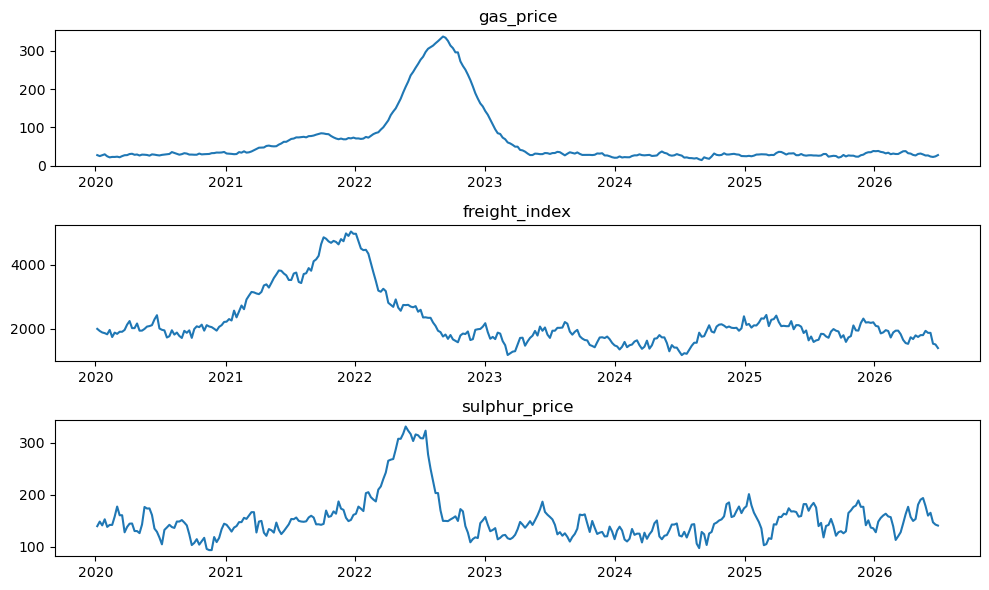

In [130]:
prices_filled = prices.copy()
prices_filled[cols_with_nans] = prices_filled[cols_with_nans].ffill()

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
axes = axes.flatten()
for i, col in enumerate(cols_with_nans):
    axes[i].plot(prices_filled.date, prices_filled[col])
    axes[i].set_title(col)
plt.tight_layout()

print("Осталось пропусков:", prices_filled.isna().sum().sum())

Проверим данные на дубликаты:

In [100]:
if prices_filled.date.is_unique:
    print("На одну дату приходится только одна строка, данные не повторяются")
else:
    print("Есть повторяющиеся даты")

На одну дату приходится только одна строка, данные не повторяются


Проверка непрерывности временного ряда:

In [116]:
prices_filled.date.diff().value_counts()

date
7 days    338
Name: count, dtype: int64

#### Корреляционный анализ

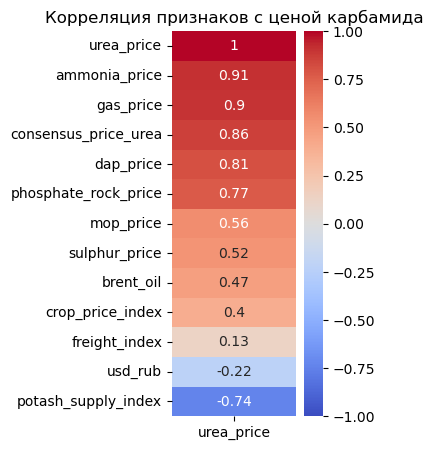

In [ ]:
corr_matrix = prices_filled.select_dtypes(include='number').corr()

urea_corr = corr_matrix[['urea_price']].sort_values(by='urea_price', ascending=False)

plt.figure(figsize=(2, 5))
sns.heatmap(urea_corr, annot=True, cmap='coolwarm',  vmin=-1, vmax=1)
plt.title('Корреляция признаков с ценой карбамида');

Цена карбамида сильнее всего коррелирует с ценами на аммиак и газ, что согласуется с производственной цепочкой.

Также наблюдаются умеренные корреляции с рядом сырьевых и макроэкономических признаков, что может говорить о наличии общего циклического движения в отрасли.

#### Анализ временных рядов и выявление аномалий

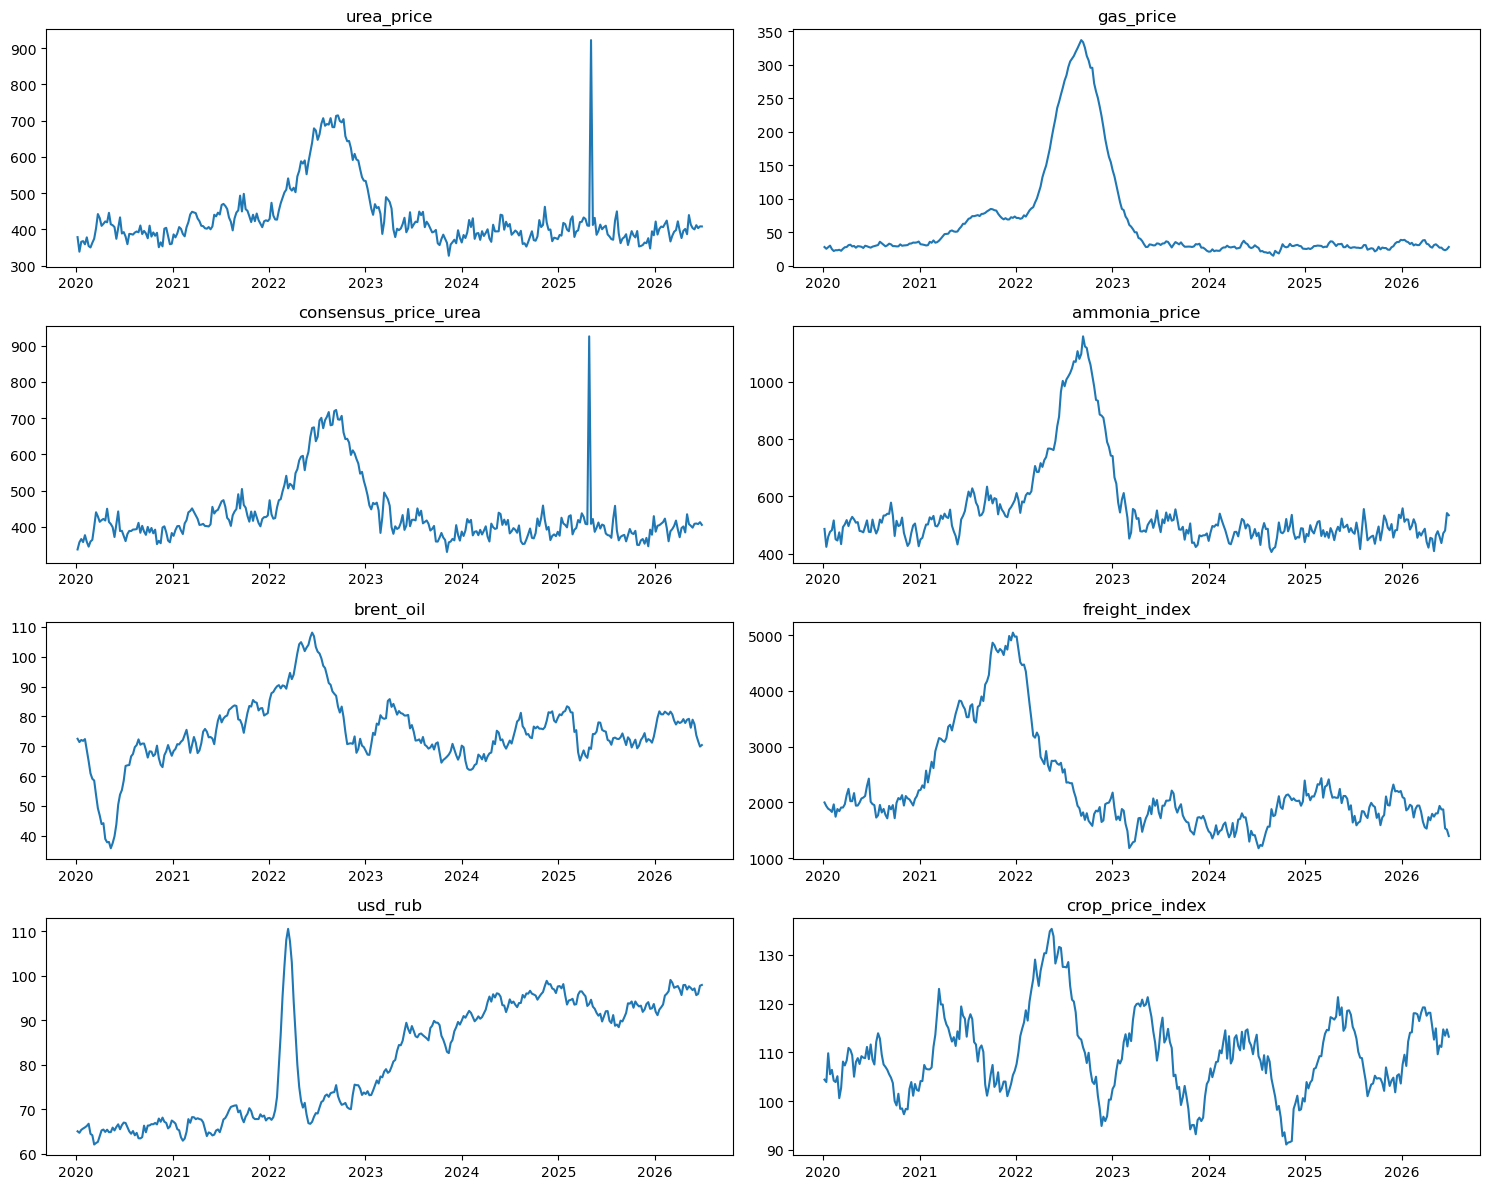

In [161]:
key_features = [
    'urea_price',      # целевой признак - цена карбамида (азотного удобрения)
    'gas_price',       # цена природного газа - сырье для аммиака
    'consensus_price_urea',
    'ammonia_price',   # цена аммиака - полупродукт для азотных удобрений
    'brent_oil',       # стоимость нефти - влияет на логистику и добычу сырья
    'freight_index',   # стоимость морских перевозок
    'usd_rub',         # доллар к рублю, влияет, так как Россия - один из крупнейших экспортеров
    'crop_price_index' # индекс цен на агрокультуры (прокси спроса на удобрения)
]

fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].plot(prices_filled.date, prices_filled[col])
    axes[i].set_title(col)

for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


Цена карбамида (`urea_price`) имеет выраженный рост в 2022 году, после которого возвращается к более стабильным значениям. Аналогичную динамику демонстрируют цены на газ и аммиак, что согласуется с гипотезой о сильной зависимости цены карбамида от стоимости сырья. 

В целевой переменной `urea_price` (и связанной `consensus_price_urea`) обнаружен экстремальный выброс в 2025 году.

График `crop_price_index` (индекс цен на агрокультуры) демонстрирует стабильную годовую сезонность, поэтому данный признак потенциально может помочь модели учитывать цикличность спроса.

В столбцах `brent_oil` и `usd_rub` присутствуют отдельные аномальные наблюдения. На данном этапе они не удаляются, так как могут отражать реальные рыночные события, однако их влияние будет учитываться при построении модели.

In [173]:
idx = prices_filled[prices_filled['urea_price'] > 750].index[0]

prices_filled.loc[idx-2:idx+2, ['date', 'urea_price']]

,date,urea_price
276,2025-04-21,410.4
277,2025-04-28,409.5
278,2025-05-05,922.0
279,2025-05-12,412.0
280,2025-05-19,431.6


Срез данных подтверждает, что аномальный скачок цены карбамида длится ровно одну неделю. Данное поведение не характерно для реального рынка и, скорее всего, является технической ошибкой в данных и требует обработки перед подачей в ML-модель. 

Для сохранения непрерывности временного ряда экстремальное значение заменим линейной интерполяцией.

In [188]:
prices_cleaned = prices_filled.copy()
prices_cleaned.loc[prices_cleaned['urea_price'] > 750, 'urea_price'] = None
prices_cleaned['urea_price'] = prices_cleaned['urea_price'].interpolate()

prices_cleaned.loc[idx-2:idx+2, ['date', 'urea_price']]

,date,urea_price
276,2025-04-21,410.40
277,2025-04-28,409.50
278,2025-05-05,410.75
279,2025-05-12,412.00
280,2025-05-19,431.60


### Исследование новостей (market_news.csv)

In [23]:
news.isna().sum()

date        0
source      0
category    0
headline    0
dtype: int64

In [102]:
print("Полных дубликатов в новостях:", news.duplicated().sum())

news_dup_count = news.duplicated(subset=['date', 'headline']).sum()
print("Дубликатов по дате и заголовку:", news_dup_count)

Полных дубликатов в новостях: 0
Дубликатов по дате и заголовку: 0


Пропусков и дубликатов в новостях нет

Для представления текстов будут рассмотрены современные методы векторизации. Конкретный метод будет выбран после построения базовой модели и оценки сложности задачи.

Было принято решение использовать Нужно не определять настроение новости, а извлекать ее смысл.

Дают ли текстовые новости дополнительную прогностическую информацию сверх уже известных рыночных факторов?